# 03 - Deteccion de Marea Roja (NDCI + FAI)
## Proyecto Boomerang - SpaceHACK 2026

Deteccion de blooms algales (marea roja) usando:
- **NDCI**: Normalized Difference Chlorophyll Index
- **FAI**: Floating Algae Index (mas robusto, menos ruido terrestre)
- **MNDWI**: Mascara de agua mejorada (reemplaza umbral fijo B3<1500)

In [11]:
import ee
import geemap
import matplotlib.pyplot as plt

ee.Initialize(project='august-tower-470819-s6')

In [12]:
# --- ROI ---
roi = ee.Geometry.Polygon([[
    [-80.23433322304784, -2.581044464678974],
    [-80.09837741250097, -2.581044464678974],
    [-80.09837741250097, -2.4212085241315013],
    [-80.23433322304784, -2.4212085241315013],
    [-80.23433322304784, -2.581044464678974]
]])

In [13]:
# --- Cargar Sentinel-2 2024 ---
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median()
    .clip(roi))

In [14]:
# --- MASCARA DE AGUA MEJORADA ---
# Bug fix: MNDWI > 0 dejaba pasar camaroneras con agua turbia y vegetacion
# Correccion: MNDWI > 0.2 (mas estricto) + NDVI < 0.3 (excluir vegetacion)

mndwi = s2.normalizedDifference(['B3', 'B11']).rename('MNDWI')
ndvi_mask = s2.normalizedDifference(['B8', 'B4']).rename('NDVI_mask')

# Agua real: MNDWI alto Y NDVI bajo (no vegetacion)
water_mask = mndwi.gt(0.2).And(ndvi_mask.lt(0.3))

# Comparar mascaras
water_mask_old = mndwi.gt(0)  # mascara anterior (buggy)

Map = geemap.Map(center=[-2.50, -80.17], zoom=12)
Map.addLayer(water_mask_old.selfMask(), {'palette': ['FF6600']}, 'Mascara VIEJA (MNDWI>0)', shown=False)
Map.addLayer(water_mask.selfMask(), {'palette': ['4169E1']}, 'Mascara NUEVA (MNDWI>0.2 + NDVI<0.3)')
Map

Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [15]:
# --- NDCI: Normalized Difference Chlorophyll Index ---
# NDCI = (B5 - B4) / (B5 + B4) sobre Sentinel-2
# B5 = Red Edge 1 (705nm), B4 = Red (665nm)
# Limitacion: se confunde con vegetacion terrestre (Yale 2025)

ndci = s2.normalizedDifference(['B5', 'B4']).rename('NDCI')
ndci_water = ndci.updateMask(water_mask)

ndci_vis = {
    'min': -0.1,
    'max': 0.2,
    'palette': [
        '0000FF',  # Azul - agua limpia
        '00FFFF',  # Cian
        'FFFF00',  # Amarillo - presencia de algas
        'FF0000'   # Rojo - marea roja
    ]
}

Map.addLayer(ndci_water, ndci_vis, 'NDCI (Clorofila)')
Map

Map(bottom=531872.0, center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], po…

In [16]:
# --- FAI: Floating Algae Index ---
# Mas robusto que NDCI para separar blooms de vegetacion terrestre
# FAI = NIR - (Red + (SWIR1 - Red) * ((832.8 - 664.6) / (1613.7 - 664.6)))
# Usando longitudes de onda centrales de Sentinel-2:
#   B4 (Red) = 664.6nm, B8 (NIR) = 832.8nm, B11 (SWIR1) = 1613.7nm

b4 = s2.select('B4').toFloat()
b8 = s2.select('B8').toFloat()
b11 = s2.select('B11').toFloat()

lambda_factor = (832.8 - 664.6) / (1613.7 - 664.6)
fai_baseline = b4.add(b11.subtract(b4).multiply(lambda_factor))
fai = b8.subtract(fai_baseline).rename('FAI')

fai_water = fai.updateMask(water_mask)

fai_vis = {
    'min': -100,
    'max': 300,
    'palette': [
        '000080',  # Azul oscuro - agua limpia
        '0000FF',  # Azul
        '00FF00',  # Verde - algas moderadas
        'FFFF00',  # Amarillo
        'FF0000'   # Rojo - bloom intenso
    ]
}

Map.addLayer(fai_water, fai_vis, 'FAI (Floating Algae Index)')
Map

Map(bottom=531872.0, center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], po…

In [21]:
# --- ZONAS DE RIESGO DE MAREA ROJA ---
# Combinar NDCI y FAI para clasificacion de riesgo

# Umbrales de riesgo
ndci_risk = ndci_water.gt(0.05)    # NDCI > 0.05 = clorofila elevada
fai_risk = fai_water.gt(50)         # FAI > 50 = presencia de algas flotantes

# Riesgo combinado: ambos indices elevados = alta probabilidad
combined_risk = ndci_risk.And(fai_risk).selfMask()
ndci_only_risk = ndci_risk.And(fai_risk.Not()).selfMask()

Map.addLayer(ndci_only_risk, {'palette': ['FFA500']}, 'Riesgo Moderado (solo NDCI)')
Map.addLayer(combined_risk, {'palette': ['FF0000']}, 'Riesgo Alto (NDCI + FAI)')
Map

Map(bottom=2127035.0, center=[-2.538298556164547, -80.14989852905273], controls=(WidgetControl(options=['posit…

In [18]:
# --- ESTADISTICAS DE CLOROFILA POR ZONA ---
ndci_stats = ndci_water.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.max(), sharedInputs=True)
        .combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

stats = ndci_stats.getInfo()
print('=== ESTADISTICAS NDCI SOBRE AGUA ===')
print(f"  Media:    {stats.get('NDCI_mean', 'N/A'):.4f}")
print(f"  Max:      {stats.get('NDCI_max', 'N/A'):.4f}")
print(f"  Min:      {stats.get('NDCI_min', 'N/A'):.4f}")
print(f"  Std Dev:  {stats.get('NDCI_stdDev', 'N/A'):.4f}")

=== ESTADISTICAS NDCI SOBRE AGUA ===
  Media:    0.1837
  Max:      0.7270
  Min:      -0.4208
  Std Dev:  0.1608


In [19]:
# --- AREA DE RIESGO (hectareas) ---
risk_area_ndci = ndci_risk.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e13
).getInfo()

risk_area_combined = combined_risk.unmask(0).multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e13
).getInfo()

print('=== AREAS DE RIESGO DE MAREA ROJA ===')
ndci_ha = list(risk_area_ndci.values())[0] / 10000 if risk_area_ndci else 0
combined_ha = list(risk_area_combined.values())[0] / 10000 if risk_area_combined else 0
print(f'  Riesgo NDCI elevado: {ndci_ha:,.1f} ha')
print(f'  Riesgo NDCI + FAI (alto): {combined_ha:,.1f} ha')

=== AREAS DE RIESGO DE MAREA ROJA ===
  Riesgo NDCI elevado: 5,207.1 ha
  Riesgo NDCI + FAI (alto): 177.7 ha


In [20]:
# --- MAPA FINAL COMPUESTO ---
Map_final = geemap.Map(center=[-2.50, -80.17], zoom=12)

# Capa base
Map_final.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, 'Sentinel-2 RGB')

# Heatmap de NDCI sobre agua
Map_final.addLayer(ndci_water, ndci_vis, 'NDCI Heatmap')

# Zonas de riesgo
Map_final.addLayer(ndci_only_risk, {'palette': ['FFA500']}, 'Riesgo Moderado')
Map_final.addLayer(combined_risk, {'palette': ['FF0000']}, 'Riesgo Alto')

legend_dict = {
    'Agua limpia': '0000FF',
    'Clorofila presente': 'FFFF00',
    'Riesgo moderado': 'FFA500',
    'Marea roja detectada': 'FF0000'
}
Map_final.add_legend(title='Deteccion Marea Roja', legend_dict=legend_dict)
Map_final

Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Serie Temporal de NDCI (2015-2024)

Mide como ha cambiado la **clorofila en el agua** a lo largo de 10 anios.
Si el NDCI sube con los anios, significa que el agua recibe cada vez mas nutrientes
(posiblemente por la intensificacion de la produccion camaronera).

Usa Sentinel-2 (disponible desde 2015) con la mascara de agua corregida.

In [22]:
# --- SERIE TEMPORAL NDCI 2015-2024 ---
# Mide clorofila en el agua por anio usando Sentinel-2
# Mascara de agua corregida: MNDWI > 0.2 + NDVI < 0.3

ndci_years = []
ndci_means = []
ndci_maxs = []

print('Calculando NDCI por anio (esto tarda unos minutos)...')
print(f'{"Anio":<6} {"NDCI medio":<12} {"NDCI max":<12}')
print('-' * 30)

for year in range(2015, 2025):
    try:
        s2_year = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(roi)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .median()
            .clip(roi))
        
        mndwi_y = s2_year.normalizedDifference(['B3', 'B11'])
        ndvi_y = s2_year.normalizedDifference(['B8', 'B4'])
        water_y = mndwi_y.gt(0.2).And(ndvi_y.lt(0.3))
        
        ndci_y = s2_year.normalizedDifference(['B5', 'B4']).updateMask(water_y)
        
        stats = ndci_y.reduceRegion(
            reducer=ee.Reducer.mean().combine(ee.Reducer.max(), sharedInputs=True),
            geometry=roi, scale=20, maxPixels=1e13
        ).getInfo()
        
        mean_val = stats.get('nd_mean', None)
        max_val = stats.get('nd_max', None)
        
        if mean_val is not None:
            ndci_years.append(year)
            ndci_means.append(mean_val)
            ndci_maxs.append(max_val)
            print(f'{year:<6} {mean_val:<12.4f} {max_val:<12.4f}')
        else:
            print(f'{year:<6} Sin datos')
    except Exception as e:
        print(f'{year:<6} Error: {e}')

print(f'\nAnios procesados: {len(ndci_years)}')

Calculando NDCI por anio (esto tarda unos minutos)...
Anio   NDCI medio   NDCI max    
------------------------------
2015   Error: Image.normalizedDifference: No band named 'B5'. Available band names: [].
2016   0.1589       0.7260      
2017   Error: Image.normalizedDifference: No band named 'B8'. Available band names: [].
2018   0.1175       0.5832      
2019   0.1582       0.6176      
2020   0.1331       0.4835      
2021   0.1419       0.4897      
2022   0.1618       0.6006      
2023   0.1699       0.6178      
2024   0.1870       0.6834      

Anios procesados: 8


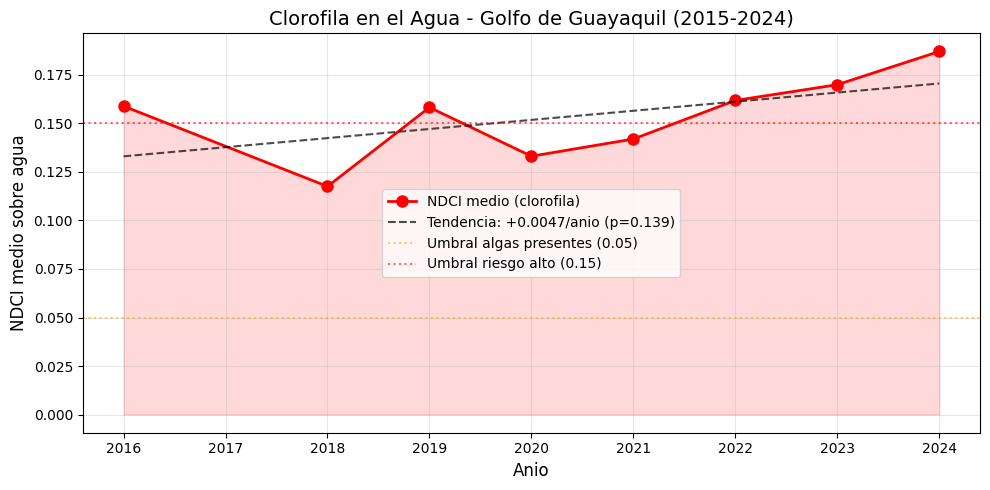


=== TENDENCIA NDCI ===
Pendiente: +0.0047 NDCI/anio
R-squared: 0.3267
p-value: 0.138841
INTERPRETACION: La clorofila en el agua AUMENTA 0.047 por decada
Esto sugiere mayor carga de nutrientes por intensificacion camaronera


In [23]:
# --- GRAFICA: Tendencia de clorofila en el agua 2015-2024 ---
from scipy import stats as sp_stats

if len(ndci_years) >= 3:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(ndci_years, ndci_means, 'r-o', linewidth=2, markersize=8, label='NDCI medio (clorofila)')
    ax.fill_between(ndci_years, ndci_means, alpha=0.15, color='red')
    
    # Tendencia lineal
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(ndci_years, ndci_means)
    trend = [slope * y + intercept for y in ndci_years]
    ax.plot(ndci_years, trend, 'k--', alpha=0.7, label=f'Tendencia: {slope:+.4f}/anio (p={p_value:.3f})')
    
    ax.axhline(y=0.05, color='orange', linestyle=':', alpha=0.6, label='Umbral algas presentes (0.05)')
    ax.axhline(y=0.15, color='red', linestyle=':', alpha=0.6, label='Umbral riesgo alto (0.15)')
    
    ax.set_xlabel('Anio', fontsize=12)
    ax.set_ylabel('NDCI medio sobre agua', fontsize=12)
    ax.set_title('Clorofila en el Agua - Golfo de Guayaquil (2015-2024)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../exports/ndci_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\n=== TENDENCIA NDCI ===')
    print(f'Pendiente: {slope:+.4f} NDCI/anio')
    print(f'R-squared: {r_value**2:.4f}')
    print(f'p-value: {p_value:.6f}')
    if slope > 0:
        print(f'INTERPRETACION: La clorofila en el agua AUMENTA {slope*10:.3f} por decada')
        print(f'Esto sugiere mayor carga de nutrientes por intensificacion camaronera')
    else:
        print(f'INTERPRETACION: La clorofila se mantiene estable o disminuye')
else:
    print('Datos insuficientes')